
# K-Means Clustering and Polynomial Regression on the Diabetes Progression Dataset  

This tutorial combines **unsupervised learning (K-means clustering)** and  
**supervised learning (polynomial regression)** on the classic **Diabetes**
regression dataset from scikit-learn.

Goals:

- Explore and visualise the diabetes dataset.
- Use **Polynomial Regression** to model a non-linear relationship between
  a selected clinical feature and disease progression.
- Use **K-Means clustering** to group patients based on key clinical attributes.
- Produce clear figures that satisfy the assignment requirements:
  - Figure 1: Histogram (distribution plot)
  - Figure 2: Scatter + polynomial regression fits (fitting)
  - Figure 3: Heatmap (correlation matrix)
  - Figure 4: Elbow plot (K-means clustering)
  - (Optional) Figure 5: PCA 2D visualisation of clusters



In [5]:

# 1. Imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

sns.set(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (9, 6)
np.random.seed(42)




## 2. Load and Inspect the Diabetes Dataset

The `load_diabetes()` dataset contains:

- 442 patients
- 10 standardised clinical features (e.g. BMI, blood pressure)
- A continuous target `y` measuring **disease progression** one year after baseline.

We convert it to a pandas DataFrame for easier analysis.



In [6]:

# 2.1 Load dataset from sklearn (no external files needed)
diabetes = load_diabetes()

X = diabetes.data        # shape (442, 10)
y = diabetes.target      # disease progression measure
feature_names = diabetes.feature_names

# Build DataFrame
df = pd.DataFrame(X, columns=feature_names)
df["target"] = y

df.head()


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0



## 3. Exploratory Data Analysis (EDA)

### 3.1 Distribution of the Target (Figure 1 – Histogram)

We start by plotting a histogram of the **disease progression** target.
This satisfies the requirement for a histogram/bar-type figure.


/opt/anaconda3/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


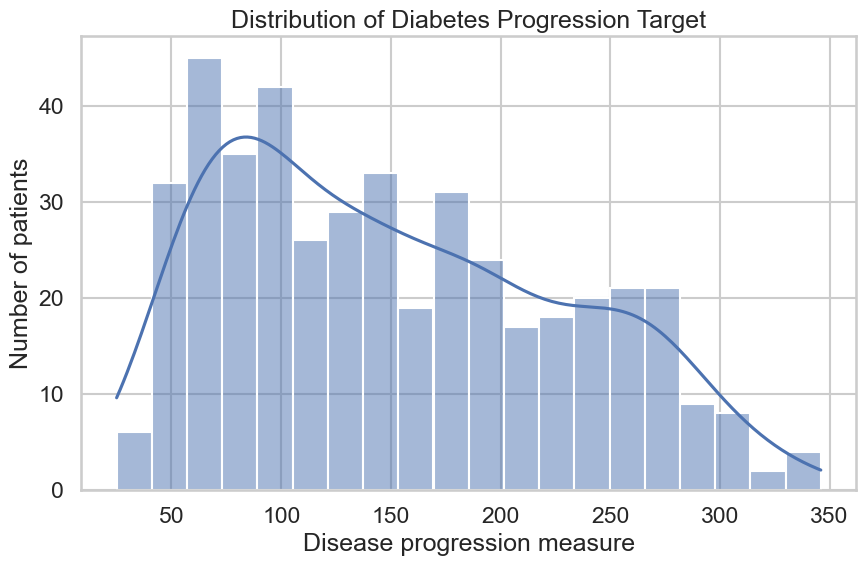

In [ ]:

# FIGURE 1: Histogram of target
plt.figure()
sns.histplot(df["target"], bins=20, kde=True)
plt.title("Distribution of Diabetes Progression Target")
plt.xlabel("Disease progression measure")
plt.ylabel("Number of patients")
plt.tight_layout()
plt.show()



### 3.2 Correlation Heatmap of Features and Target (Figure 2 – Heatmap)

Next, we compute the correlation matrix and show it as a heatmap.
This satisfies the heatmap requirement and also helps us pick
a feature for polynomial regression.



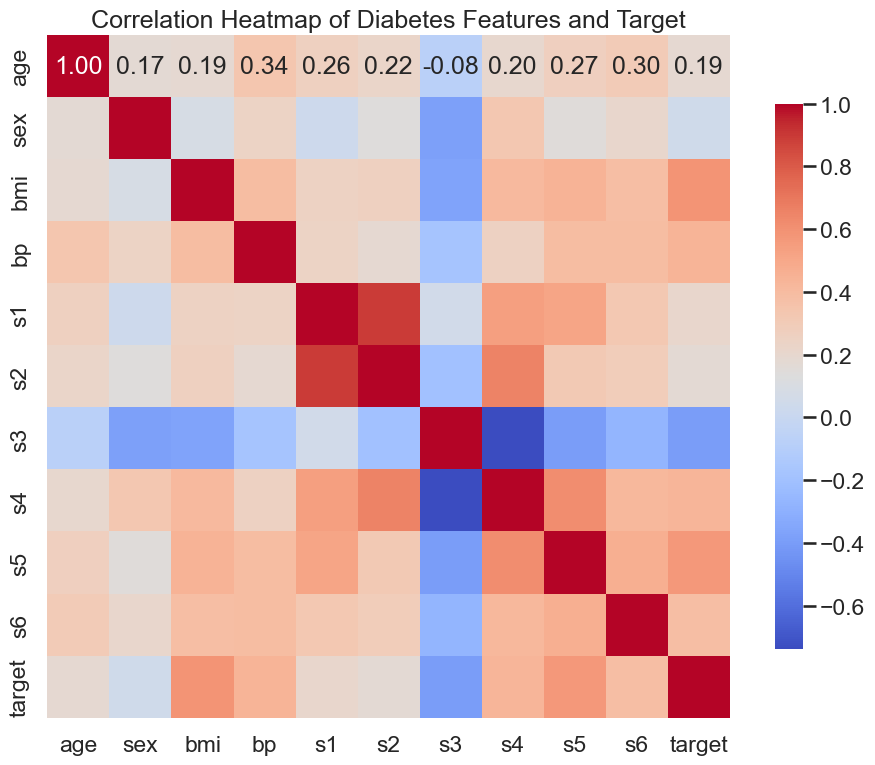

In [8]:

# FIGURE 2: Correlation heatmap
corr = df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    cbar_kws={"shrink": 0.8},
)
plt.title("Correlation Heatmap of Diabetes Features and Target")
plt.tight_layout()
plt.show()




From the heatmap, one of the strongest correlations with `target` is usually
the **bmi** (body mass index) feature.

We will now use **bmi** as the predictor in a polynomial regression model
for the target.


In [9]:

# 4. Polynomial Regression: Target vs BMI

# Select feature 'bmi' for regression
X_bmi = df[["bmi"]].values  # (N, 1)
y_target = df["target"].values

# For smooth plotting, sort by bmi
sort_idx = np.argsort(X_bmi[:, 0])
X_bmi_sorted = X_bmi[sort_idx]
y_sorted = y_target[sort_idx]


In [10]:
# %% 
# Helper to build polynomial regression pipeline
def make_poly_model(degree):
    return Pipeline(
        [
            ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
            ("linreg", LinearRegression()),
        ]
    )

degrees = [1, 2, 3]
models = {}

for d in degrees:
    model = make_poly_model(d)
    model.fit(X_bmi, y_target)
    models[d] = model

# Compute and print MSE for each degree
for d, model in models.items():
    mse = mean_squared_error(y_target, model.predict(X_bmi))
    print(f"Degree {d}: MSE = {mse:.2f}")


Degree 1: MSE = 3890.46
Degree 2: MSE = 3889.70
Degree 3: MSE = 3883.35


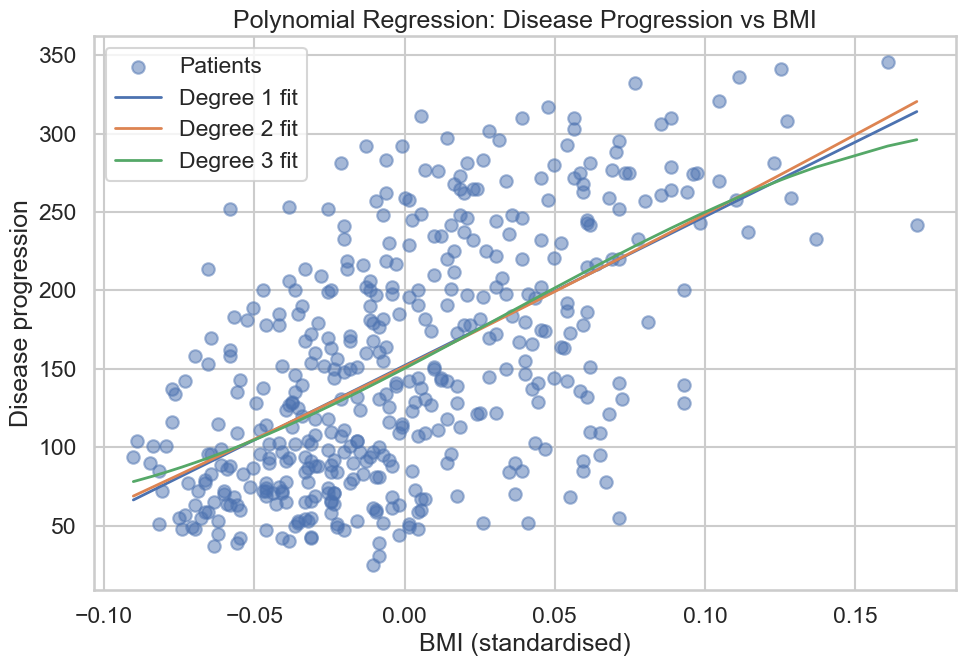

In [11]:
# %% 
# FIGURE 3: Scatter + polynomial regression fits
plt.figure(figsize=(10, 7))

# Scatter of patients
plt.scatter(X_bmi, y_target, alpha=0.5, label="Patients")

# Smooth curves
X_plot = X_bmi_sorted
for d, model in models.items():
    y_pred = model.predict(X_plot)
    plt.plot(
        X_plot[:, 0],
        y_pred,
        linewidth=2,
        label=f"Degree {d} fit",
    )

plt.title("Polynomial Regression: Disease Progression vs BMI")
plt.xlabel("BMI (standardised)")
plt.ylabel("Disease progression")
plt.legend()
plt.tight_layout()
plt.show()



## 5. K-Means Clustering on Clinical Features  

Next, we perform **K-Means clustering** on a subset of meaningful features:

- `bmi`
- `bp` (blood pressure)
- `s1` (tc – total serum cholesterol)
- `s2` (ldl – low-density lipoproteins)
- `s3` (hdl – high-density lipoproteins)
- `s4` (tch – total cholesterol / HDL)
- `s5` (ltg – possibly log of serum triglycerides)
- `s6` (glu – blood sugar level)

We standardise the features first because K-Means is sensitive to scale.



In [12]:
# %% 
cluster_cols = ["bmi", "bp", "s1", "s2", "s3", "s4", "s5", "s6"]
X_cluster = df[cluster_cols].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)
X_scaled.shape


(442, 8)


### 5.1 Elbow Plot for Choosing K (Figure 4 – Elbow Curve)

We run K-Means for different K values (1–10) and plot the **inertia**
(within-cluster sum of squared distances). The “elbow” in this curve
suggests a good trade-off between the number of clusters and how compact
they are.



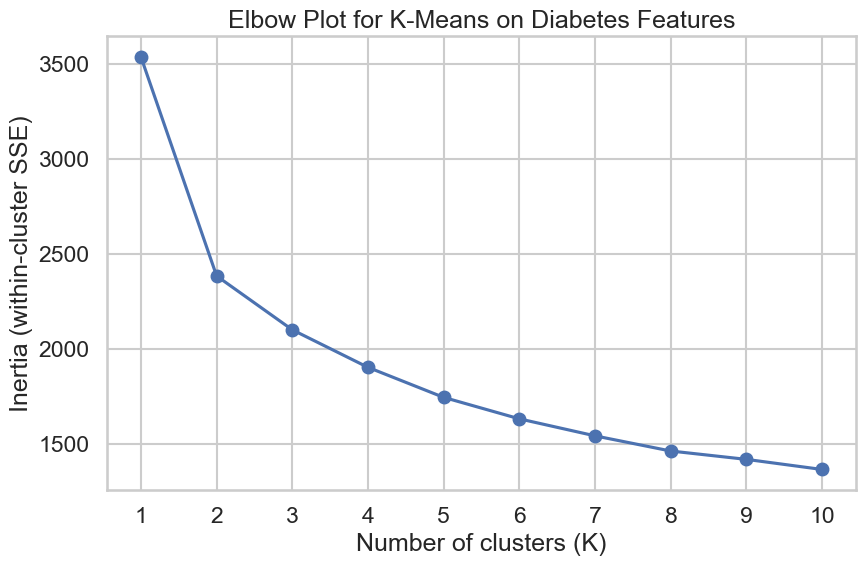

In [13]:

# FIGURE 4: Elbow plot
inertias = []
K_values = range(1, 11)

for k in K_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure()
plt.plot(K_values, inertias, marker="o")
plt.xticks(K_values)
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia (within-cluster SSE)")
plt.title("Elbow Plot for K-Means on Diabetes Features")
plt.tight_layout()
plt.show()



By inspecting the elbow curve, we choose a reasonable number of clusters.
For many runs on this dataset, **K ≈ 3** is a sensible choice.

We now fit the final K-Means model with `K = 3`.



In [14]:
# %% 
K_CHOSEN = 3

kmeans_final = KMeans(n_clusters=K_CHOSEN, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_scaled)

df["cluster"] = cluster_labels
df["cluster"].value_counts().sort_index()


cluster
0    107
1    195
2    140
Name: count, dtype: int64


### 5.2 PCA Projection of Clusters (Figure 5 – Optional but Strong)

To visualise clusters in 2D, we apply **PCA** to the scaled features and
colour points by assigned cluster.



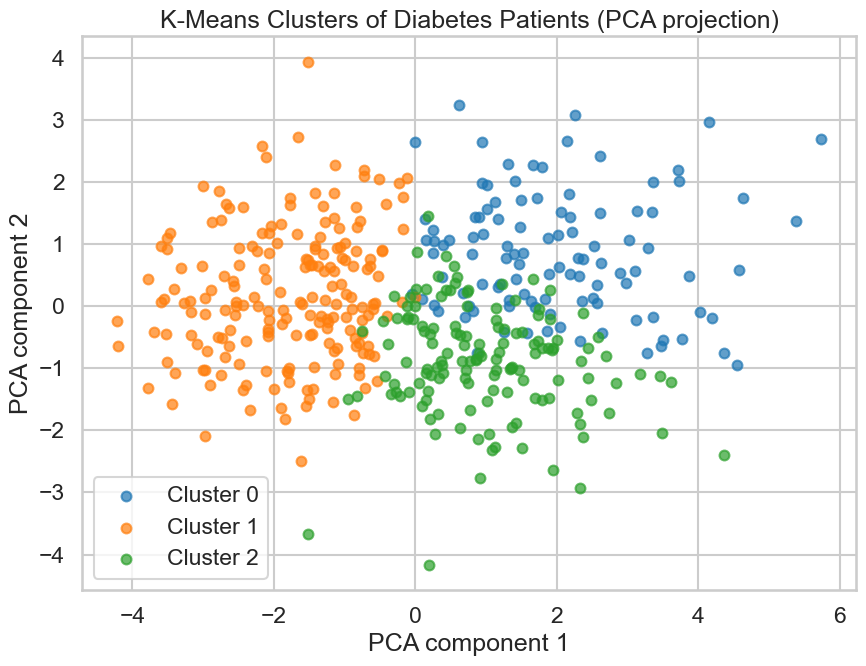

In [15]:

# FIGURE 5 (optional): PCA 2D scatter of clusters
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(9, 7))
palette = sns.color_palette("tab10", K_CHOSEN)

for k in range(K_CHOSEN):
    mask = cluster_labels == k
    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        s=50,
        alpha=0.7,
        color=palette[k],
        label=f"Cluster {k}",
    )

plt.xlabel("PCA component 1")
plt.ylabel("PCA component 2")
plt.title("K-Means Clusters of Diabetes Patients (PCA projection)")
plt.legend()
plt.tight_layout()
plt.show()




### 5.3 Cluster-Level Summary Statistics

We now compute mean values of the clinical features and target for each
cluster to help interpret them.



In [16]:

cluster_cols_plus_target = cluster_cols + ["target"]
cluster_summary = df.groupby("cluster")[cluster_cols_plus_target].mean().round(2)
cluster_summary


,bmi,bp,s1,s2,s3,s4,s5,s6,target
cluster,,,,,,,,,
0,0.01,0.00,0.06,0.06,-0.02,0.05,0.03,0.02,171.40
1,-0.03,-0.03,-0.03,-0.03,0.03,-0.04,-0.04,-0.03,106.59
2,0.03,0.04,-0.01,-0.01,-0.02,0.01,0.03,0.02,200.84



## 6. Key Numeric Results for the Report

Finally, we store numeric summaries that will be quoted in the written
report for Faizan:

- MSE by polynomial degree (1, 2, 3).
- Number of patients in each cluster.
- Mean disease progression per cluster.



In [17]:

# MSE by degree
mse_by_degree = {
    d: float(mean_squared_error(y_target, model.predict(X_bmi)))
    for d, model in models.items()
}
print("MSE by polynomial degree:", mse_by_degree)

# Cluster sizes
cluster_sizes = df["cluster"].value_counts().sort_index()
print("\nPatients per cluster:\n", cluster_sizes)

# Mean target by cluster
target_by_cluster = df.groupby("cluster")["target"].mean().round(2)
print("\nMean disease progression per cluster:\n", target_by_cluster)


MSE by polynomial degree: {1: 3890.456585461273, 2: 3889.702145270231, 3: 3883.351178536732}

Patients per cluster:
 cluster
0    107
1    195
2    140
Name: count, dtype: int64

Mean disease progression per cluster:
 cluster
0    171.40
1    106.59
2    200.84
Name: target, dtype: float64
